In [2]:
!pip install matplotlib

/Users/dhairyabhatt/code_dir/Data analytics projects/world_health/world_bank/bin/pip: line 2: /Users/dhairyabhatt/code_dir/Data analytics projects/world_bank/world_bank/bin/python: No such file or directory
/Users/dhairyabhatt/code_dir/Data analytics projects/world_health/world_bank/bin/pip: line 2: exec: /Users/dhairyabhatt/code_dir/Data analytics projects/world_bank/world_bank/bin/python: cannot execute: No such file or directory


In [1]:
# Cell 1 — Load & Inspect Q10 Dataset

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = "/Users/dhairyabhatt/code_dir/Data analytics projects/world_health/data"
OUTPUT_PATH = os.path.join(BASE_PATH, "phase3_outputs")

q10 = pd.read_csv(os.path.join(OUTPUT_PATH, "q10_ntd_trend.csv"))

print(q10.shape)
print(q10.dtypes)
q10.head()

(1746, 3)
country      str
year       int64
value      int64
dtype: object


,country,year,value
0,Afghanistan,2018,14834701
1,Afghanistan,2017,14786722
2,Afghanistan,2016,13275429
3,Afghanistan,2015,13765392
4,Afghanistan,2014,13384908


In [2]:
# Cell 2 — Global Yearly Total & Year-on-Year Change

global_ntd = q10.groupby("year")["value"].sum().reset_index()
global_ntd["yoy_change"] = global_ntd["value"].diff()
global_ntd["yoy_pct_change"] = global_ntd["value"].pct_change() * 100

global_ntd

,year,value,yoy_change,yoy_pct_change
0,2010,2153322725,NaN,NaN
1,2011,2136281434,-17041291.0,-0.791395
2,2012,2082624672,-53656762.0,-2.511690
3,2013,1981912451,-100712221.0,-4.835832
4,2014,1874175324,-107737127.0,-5.436018
5,2015,1755574437,-118600887.0,-6.328164
6,2016,1674345541,-81228896.0,-4.626913
7,2017,1756707024,82361483.0,4.919025
8,2018,1755185122,-1521902.0,-0.086634


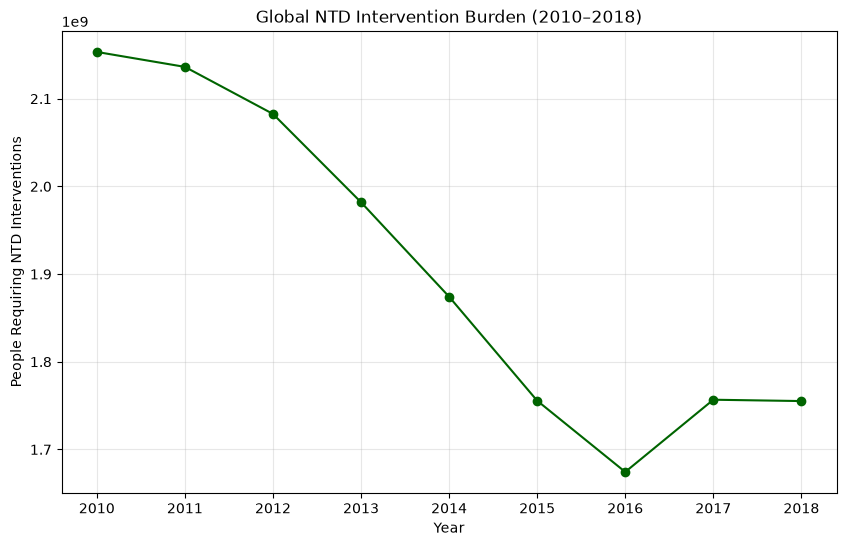

In [3]:
# Cell 3 — Plot Global NTD Burden Trend (2010–2018)

plt.figure(figsize=(10, 6))
plt.plot(global_ntd["year"], global_ntd["value"], marker="o", color="darkgreen")
plt.xlabel("Year")
plt.ylabel("People Requiring NTD Interventions")
plt.title("Global NTD Intervention Burden (2010–2018)")
plt.grid(alpha=0.3)
plt.show()

In [4]:
# Cell 4 — Top 15 Countries by Absolute Burden (Latest Year)
# Snapshot approach, consistent with how country rankings were handled for Q2

latest_year = q10["year"].max()
latest = q10[q10["year"] == latest_year].copy()

total_global = latest["value"].sum()
latest["pct_of_global"] = latest["value"] / total_global * 100

top15 = latest.sort_values("value", ascending=False).head(15)
top15[["country", "value", "pct_of_global"]]

,country,value,pct_of_global
702,India,697000000,39.710911
1125,Nigeria,131000000,7.463600
711,Indonesia,101000000,5.754379
531,Ethiopia,77653029,4.424207
117,Bangladesh,56339394,3.209883
423,Democratic Republic of the Congo,52756552,3.005754
1215,Philippines,47078380,2.682246
1053,Myanmar,41778536,2.380292
1161,Pakistan,31683212,1.805121
1656,United Republic of Tanzania,26707925,1.521659


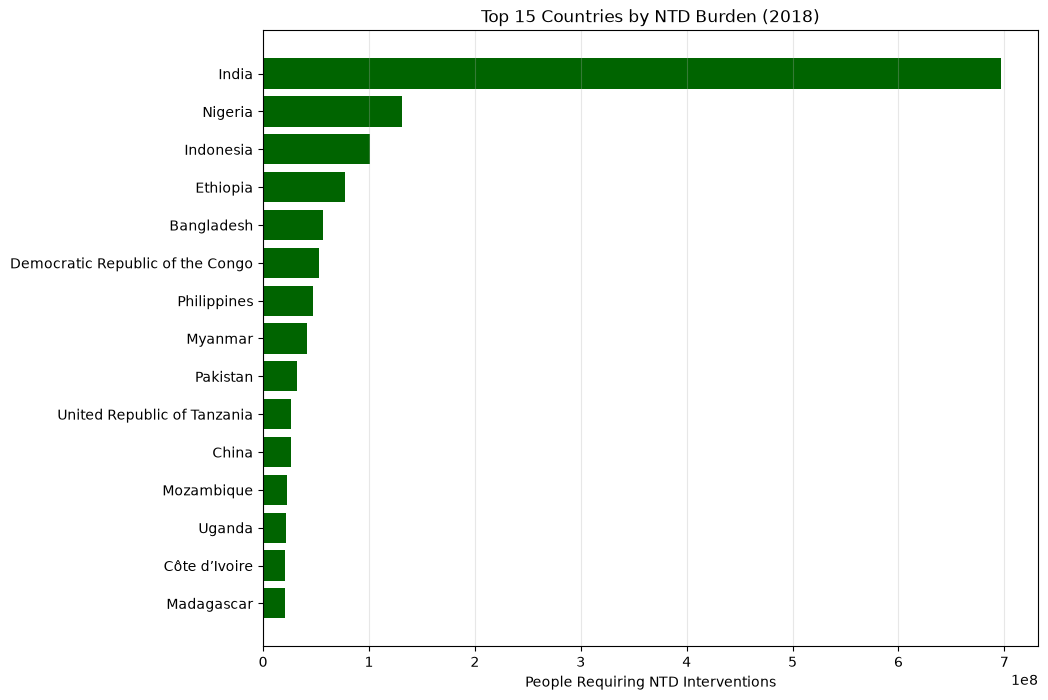

Top 15 countries account for 78.3% of the global NTD burden in 2018


In [5]:
# Cell 5 — Plot Top 15 Countries by NTD Burden

plt.figure(figsize=(10, 8))
plt.barh(top15["country"], top15["value"], color="darkgreen")
plt.xlabel("People Requiring NTD Interventions")
plt.title(f"Top 15 Countries by NTD Burden ({latest_year})")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()

print(f"Top 15 countries account for {top15['value'].sum() / total_global * 100:.1f}% "
      f"of the global NTD burden in {latest_year}")

In [6]:
# Cell 6 — Country-Level Change: 2010 vs 2018

pivot = q10[q10["year"].isin([2010, 2018])].pivot(
    index="country", columns="year", values="value"
)
pivot.columns = ["count_2010", "count_2018"]
pivot = pivot.dropna().reset_index()
pivot["abs_change"] = pivot["count_2018"] - pivot["count_2010"]

pivot.head()

,country,count_2010,count_2018,abs_change
0,Afghanistan,12246738.0,14834701.0,2587963.0
1,Albania,61.0,47.0,-14.0
2,Algeria,10260.0,10909.0,649.0
3,Andorra,0.0,0.0,0.0
4,Angola,15879207.0,15220708.0,-658499.0


In [7]:
# Cell 7 — Largest Reductions and Largest Increases (2010 → 2018)

largest_reductions = pivot.sort_values("abs_change").head(10)
largest_increases = pivot.sort_values("abs_change", ascending=False).head(10)

print("Largest absolute reductions:")
print(largest_reductions[["country", "count_2010", "count_2018", "abs_change"]])

print("\nLargest absolute increases:")
print(largest_increases[["country", "count_2010", "count_2018", "abs_change"]])

Largest absolute reductions:
                         country   count_2010   count_2018   abs_change
78                         India  837000000.0  697000000.0 -140000000.0
79                     Indonesia  157000000.0  101000000.0  -56000000.0
13                    Bangladesh  102000000.0   56339394.0  -45660606.0
129                     Pakistan   69714319.0   31683212.0  -38031107.0
35                         China   52000000.0   26378300.0  -25621700.0
53                         Egypt   24000000.0    5066393.0  -18933607.0
23                        Brazil   27000000.0    9489512.0  -17510488.0
183  United Republic of Tanzania   43656348.0   26707925.0  -16948423.0
120                        Nepal   26834231.0   14520580.0  -12313651.0
89                         Kenya   21811703.0   11645569.0  -10166134.0

Largest absolute increases:
                                   country   count_2010   count_2018  \
160                           South Africa    6144429.0   18807465.0   
59    

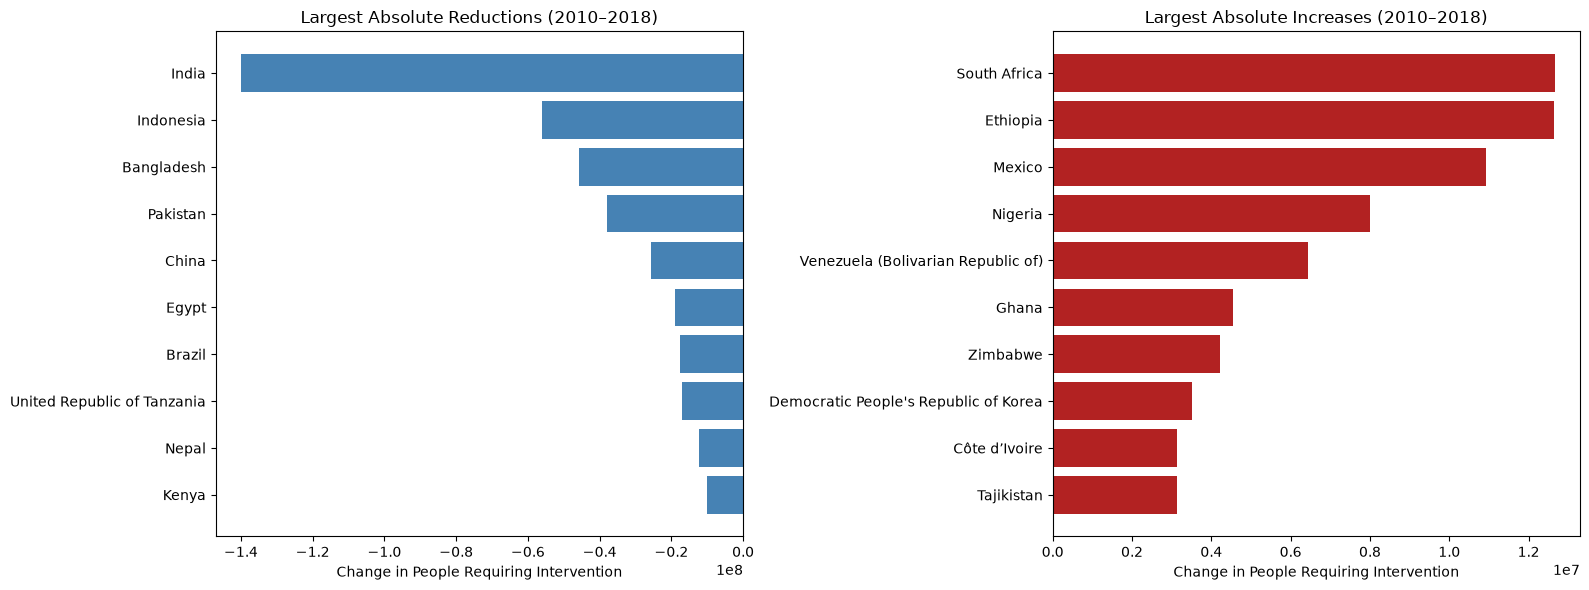

In [8]:
# Cell 8 — Plot Largest Reductions vs Largest Increases

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(largest_reductions["country"], largest_reductions["abs_change"], color="steelblue")
axes[0].set_title("Largest Absolute Reductions (2010–2018)")
axes[0].set_xlabel("Change in People Requiring Intervention")
axes[0].invert_yaxis()

axes[1].barh(largest_increases["country"], largest_increases["abs_change"], color="firebrick")
axes[1].set_title("Largest Absolute Increases (2010–2018)")
axes[1].set_xlabel("Change in People Requiring Intervention")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()